# Modelo no supervisado sobre el dataset L1
Se busca interpretar  que clusters se generan sobre el conjunto de datos seleccionado *(71 imagenes a 4 bandas, r,g,b,NIR)*

In [ ]:
import os
import tifffile as tiff
import numpy as np

# 🔹 Pega aquí tu ruta
data_dir = r"E:\MACHINE LEARNING\AVANZADO 1\VSFOLDER A1 PROYECT\OT-Detecci-n-de-objetos-VIS-NIR-ML-Colombia\src\Multiespectral_Data"

# 🔹 Leer imágenes directamente
imgs = []
for filename in os.listdir(data_dir):
    if filename.endswith(".tiff"):
        path = os.path.join(data_dir, filename)
        img = tiff.imread(path)
        imgs.append(img)

# 🔹 Mostrar información
print(f"Se cargaron {len(imgs)} imágenes.")
if len(imgs) > 0:
    print(f"Cada imagen tiene la forma: {imgs[0].shape}")
else:
    print("⚠️ No se encontraron imágenes TIFF en la carpeta.")


Se cargaron 72 imágenes.
Cada imagen tiene la forma: (1944, 2592, 4)


In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np
from tqdm import tqdm  # para mostrar progreso

# 🔹 1. Apilar todas las imágenes en un solo arreglo 4D
# Muestra el progreso imagen por imagen
print("📦 Apilando imágenes...")
X_list = []
for i, img in enumerate(tqdm(imgs, desc="Apilando", unit="imagen")):
    X_list.append(img)
X = np.stack(X_list, axis=0)
print(f"✅ Forma del dataset completo: {X.shape}")

# 🔹 2. Convertir cada píxel en un vector [R,G,B,NIR]
print("🔁 Reestructurando datos para clustering...")
X_reshaped = X.reshape(-1, 4)
print(f"✅ Datos reestructurados: {X_reshaped.shape}")

# 🔹 3. Normalizar (cada banda con media 0, varianza 1)
print("⚙️ Normalizando bandas (esto puede tardar unos minutos)...")
scaler = StandardScaler()

# Aquí también se muestra una barra de progreso simulada
# mientras el proceso se ejecuta (StandardScaler no tiene callback)
from time import sleep
from threading import Thread

def fake_progress():
    for i in tqdm(range(100), desc="Normalizando", unit="%"):
        sleep(0.05)

thread = Thread(target=fake_progress)
thread.start()

X_scaled = scaler.fit_transform(X_reshaped)

thread.join()
print("✅ Datos normalizados correctamente.")


📦 Apilando imágenes...


Apilando: 100%|██████████| 72/72 [00:00<00:00, 71274.46imagen/s]


✅ Forma del dataset completo: (72, 1944, 2592, 4)
🔁 Reestructurando datos para clustering...
✅ Datos reestructurados: (362797056, 4)
⚙️ Normalizando bandas (esto puede tardar unos minutos)...


Normalizando: 100%|██████████| 100/100 [00:05<00:00, 18.64%/s]


✅ Datos normalizados correctamente.


🔍 Aplicando PCA...
✅ Variancia explicada: 97.52%


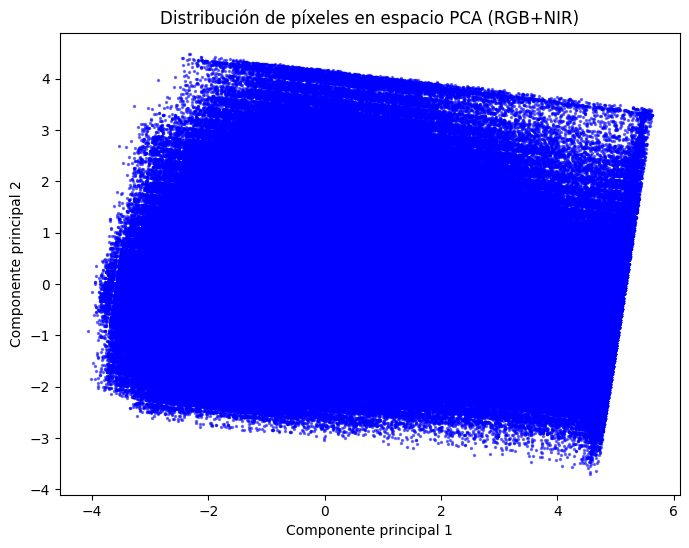

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 🔹 1. Aplicar PCA para reducir de 4 a 2 dimensiones
print("🔍 Aplicando PCA...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"✅ Variancia explicada: {pca.explained_variance_ratio_.sum():.2%}")

# 🔹 2. Visualizar los píxeles en el espacio PCA
plt.figure(figsize=(8,6))
plt.scatter(X_pca[::100, 0], X_pca[::100, 1], s=2, alpha=0.5, c='blue')  # Muestra 1 de cada 100 píxeles
plt.title("Distribución de píxeles en espacio PCA (RGB+NIR)")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.show()



In [ ]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Supongamos que ya tienes X_scaled de la etapa anterior
# Tomamos una muestra aleatoria (por ejemplo 1% de los píxeles)
sample_ratio = 0.001  # 1% de los píxeles
sample_size = int(X_scaled.shape[0] * sample_ratio)
indices = np.random.choice(X_scaled.shape[0], sample_size, replace=False)

X_sample = X_scaled[indices]

print(f"Usando una muestra de {sample_size:,} píxeles ({sample_ratio*100:.1f}%)")

# Aplicamos PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sample)

print("✅ PCA completado sobre la muestra")


Usando una muestra de 3,627,970 píxeles (1.0%)
✅ PCA completado sobre la muestra


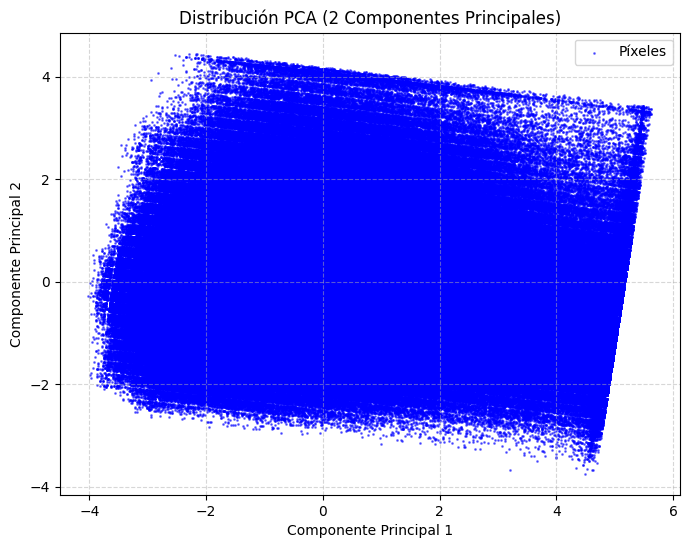

In [ ]:
import matplotlib.pyplot as plt

# Visualizar los dos primeros componentes principales
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], 
            s=1, c='blue', alpha=0.5, label='Píxeles')

plt.title("Distribución PCA (2 Componentes Principales)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()



In [ ]:
from sklearn.cluster import KMeans
import numpy as np

# 🔹 Definir número de clusters (puedes ajustar según tu caso)
n_clusters = 5 # por ejemplo: suelo, agua, vegetación, construcciones, carreteras

print(f"🏁 Ejecutando K-Means con {n_clusters} clusters...")

# 🔹 Entrenar el modelo
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_pca)

print("✅ K-Means completado.")
print(f"Centroides encontrados: {kmeans.cluster_centers_.shape}")


🏁 Ejecutando K-Means con 5 clusters...
✅ K-Means completado.
Centroides encontrados: (5, 2)


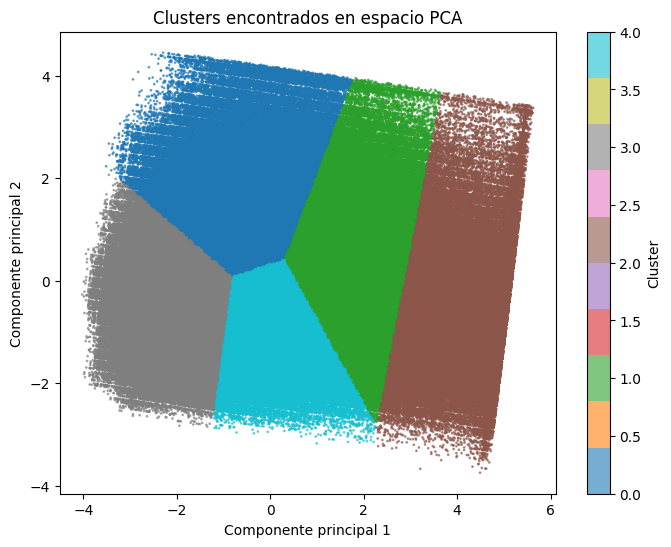

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels,
    s=1,
    cmap="tab10",  # paleta de 10 colores
    alpha=0.6
)

plt.title("Clusters encontrados en espacio PCA")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.colorbar(scatter, label="Cluster")
plt.show()


In [ ]:
import numpy as np

n_clusters = kmeans.n_clusters

sample_indices = np.random.choice(X_scaled.shape[0], sample_size, replace=False)
X_sample = X_scaled[sample_indices]
X_pca_sample = pca.fit_transform(X_sample)
labels_sample = kmeans.fit_predict(X_pca_sample)

for i in range(n_clusters):
    cluster_pixels = X_sample[labels_sample == i]  # correcto: mismo tamaño
  # todos los píxeles del cluster i
    print(f"\nCluster {i}:")
    print(f" - Número de píxeles: {cluster_pixels.shape[0]}")
    print(f" - Media por banda (R,G,B,NIR): {cluster_pixels.mean(axis=0)}")
    print(f" - Desviación estándar por banda: {cluster_pixels.std(axis=0)}")



Cluster 0:
 - Número de píxeles: 13729
 - Media por banda (R,G,B,NIR): [ 0.08015412  0.05331464  0.12141523 -0.62308335]
 - Desviación estándar por banda: [0.40502817 0.32903107 0.40523977 0.54425469]

Cluster 1:
 - Número de píxeles: 11243
 - Media por banda (R,G,B,NIR): [-0.4548098  -0.43448064 -0.46789715  0.92382457]
 - Desviación estándar por banda: [0.40057506 0.37463264 0.42020787 0.69742479]

Cluster 2:
 - Número de píxeles: 3660
 - Media por banda (R,G,B,NIR): [2.40900412 2.57086568 2.48292429 0.22920617]
 - Desviación estándar por banda: [0.30031038 0.59695653 0.58265596 1.22587834]

Cluster 3:
 - Número de píxeles: 8698
 - Media por banda (R,G,B,NIR): [0.84692345 0.75396872 0.70176675 0.60254429]
 - Desviación estándar por banda: [0.4972142  0.37472702 0.46382256 0.82663259]

Cluster 4:
 - Número de píxeles: 12670
 - Media por banda (R,G,B,NIR): [-0.96885813 -0.94494932 -0.92402294 -0.64172004]
 - Desviación estándar por banda: [0.35594781 0.34078142 0.38946581 0.64419875]


In [ ]:
# Centroides en el espacio PCA
print("Centroides en PCA:", kmeans.cluster_centers_)

# Centroides en el espacio original
centroids_original = kmeans.cluster_centers_ @ pca.components_ + pca.mean_
print("Centroides aproximados en escala normalizada original:", centroids_original)


Centroides en PCA: [[ 0.06823701 -0.63639507]
 [-0.64267275  1.02686722]
 [ 4.30164009 -0.37911509]
 [ 1.40564129  0.41999951]
 [-1.70517999 -0.40232104]]
Centroides aproximados en escala normalizada original: [[ 0.08157085  0.07427455  0.10982735 -0.62413652]
 [-0.44196327 -0.43666713 -0.48263967  0.92042412]
 [ 2.48686891  2.51170652  2.46238452  0.22841028]
 [ 0.77309438  0.78622886  0.74023831  0.60960494]
 [-0.94999599 -0.96714992 -0.91522913 -0.64318   ]]



Cluster 0:
 - Número de píxeles: 13729
 - Media por banda (R,G,B,NIR): [ 0.08015412  0.05331464  0.12141523 -0.62308335]
 - Desviación estándar por banda: [0.40502817 0.32903107 0.40523977 0.54425469]
 - Rango por banda: [-0.76180766 -0.61396126 -0.78746912 -2.94891715] - [2.4873266  1.51009497 2.07821146 0.43152191]

Cluster 1:
 - Número de píxeles: 11243
 - Media por banda (R,G,B,NIR): [-0.4548098  -0.43448064 -0.46789715  0.92382457]
 - Desviación estándar por banda: [0.40057506 0.37463264 0.42020787 0.69742479]
 - Rango por banda: [-2.16976584 -2.12440125 -2.18478444 -0.11062397] - [0.77611589 0.56606998 0.822996   4.13087032]

Cluster 2:
 - Número de píxeles: 3660
 - Media por banda (R,G,B,NIR): [2.40900412 2.57086568 2.48292429 0.22920617]
 - Desviación estándar por banda: [0.30031038 0.59695653 0.58265596 1.22587834]
 - Rango por banda: [ 1.20933379  1.1560856   0.822996   -2.82135341] - [2.66061376 3.16213871 3.04922719 4.09897939]

Cluster 3:
 - Número de píxeles: 8698
 - Med

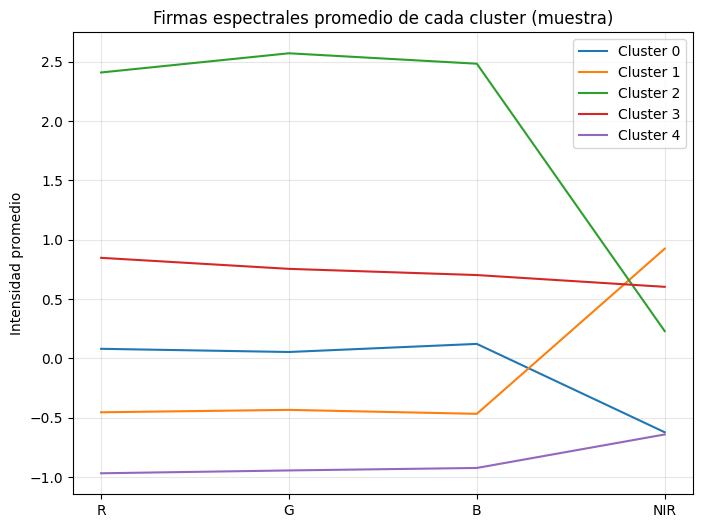

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 🔹 Asegurarse de usar la misma muestra que se usó para PCA y K-Means
X_sample  # tus datos normalizados de la muestra (X_scaled[sample_indices])
labels_sample = kmeans.labels_  # etiquetas del K-Means entrenado sobre la muestra
n_clusters = kmeans.n_clusters

# 🔹 Crear diccionario de estadísticas por cluster
cluster_stats = {}

for i in range(n_clusters):
    cluster_pixels = X_sample[labels_sample == i]
    cluster_stats[i] = {
        'n_pixels': cluster_pixels.shape[0],
        'mean': cluster_pixels.mean(axis=0),
        'std': cluster_pixels.std(axis=0),
        'min': cluster_pixels.min(axis=0),
        'max': cluster_pixels.max(axis=0)
    }

# 🔹 Mostrar resumen
for i in range(n_clusters):
    print(f"\nCluster {i}:")
    print(f" - Número de píxeles: {cluster_stats[i]['n_pixels']}")
    print(f" - Media por banda (R,G,B,NIR): {cluster_stats[i]['mean']}")
    print(f" - Desviación estándar por banda: {cluster_stats[i]['std']}")
    print(f" - Rango por banda: {cluster_stats[i]['min']} - {cluster_stats[i]['max']}")

# 🔹 Graficar firmas espectrales promedio de los clusters
plt.figure(figsize=(8,6))
for i in range(n_clusters):
    plt.plot([0,1,2,3], cluster_stats[i]['mean'], label=f'Cluster {i}')
plt.xticks([0,1,2,3], ['R','G','B','NIR'])
plt.ylabel('Intensidad promedio')
plt.title('Firmas espectrales promedio de cada cluster (muestra)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


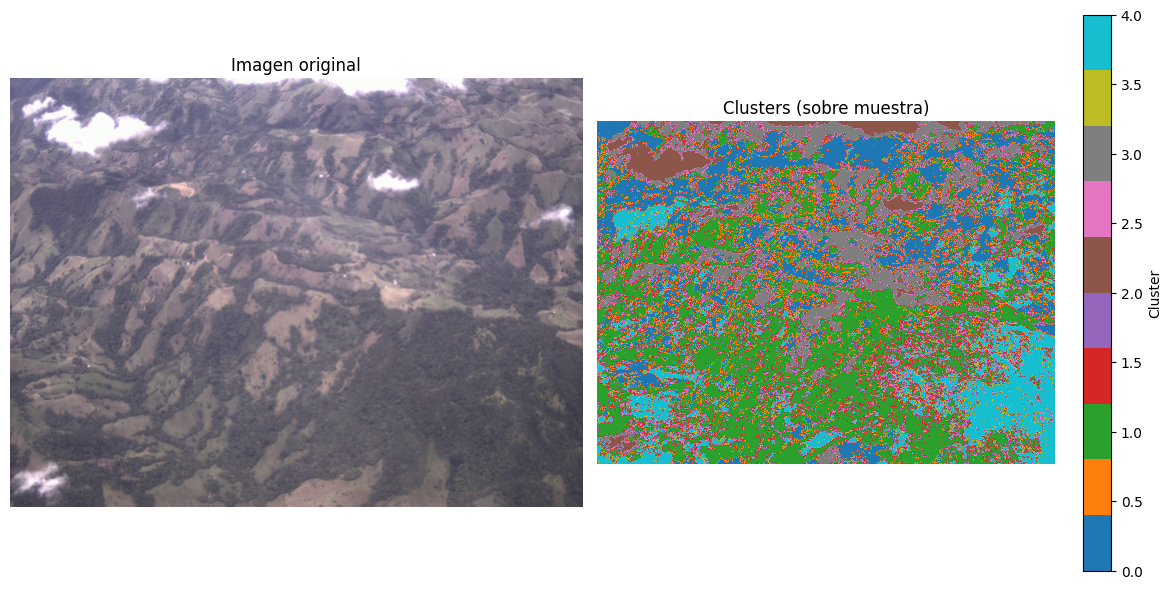

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Selecciona la imagen ---
example_img = imgs[30]
h, w, c = example_img.shape

# --- Escoger una muestra de píxeles de la imagen individual ---
n_samples = min(50000000, h * w)
sample_indices_img = np.random.choice(h * w, n_samples, replace=False)
pixels = example_img.reshape(-1, c)[sample_indices_img]

# --- Normalizar y proyectar al PCA ---
pixels_scaled = scaler.transform(pixels)
pixels_pca = pca.transform(pixels_scaled)
pixels_labels = kmeans.predict(pixels_pca)

# --- Reconstruir mapa de clusters solo para la imagen ---
img_cluster_map = np.full((h*w), fill_value=-1, dtype=int)
img_cluster_map[sample_indices_img] = pixels_labels
img_cluster_map = img_cluster_map.reshape(h, w)

# --- Visualización lado a lado ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Imagen original (RGB)
axes[0].imshow(example_img[..., :3])
axes[0].set_title("Imagen original")
axes[0].axis('off')

# Imagen con clusters
im = axes[1].imshow(img_cluster_map, cmap='tab10')
axes[1].set_title("Clusters (sobre muestra)")
axes[1].axis('off')

fig.colorbar(im, ax=axes[1], label="Cluster")
plt.tight_layout()
plt.show()
